# Multi-factor research pipeline

配置化的多因子研究流程：数据准备、因子构造、横截面变换和评估彼此解耦。新增因子时只需扩展 `FACTOR_SPECS`，无需复制标准化、分组或绘图代码。

In [212]:
from __future__ import annotations

from collections.abc import Callable, Sequence
from dataclasses import dataclass
from datetime import datetime, timedelta
from math import ceil

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from trend_trader.data.models import bar_minutes

pl.Config.set_tbl_rows(10)

polars.config.Config

## 1. Configuration and factor registry

In [213]:
@dataclass(frozen=True)
class AnalysisConfig:
    candles_path: str = (
        "../data/market/v1/offline/normalized/candles/"
        "venue=BINANCE/year=*/date=*/*.parquet"
    )
    funding_rates_path: str = (
        "../data/market/v1/offline/normalized/funding_rates/"
        "venue=BINANCE/year=*/date=*/*.parquet"
    )
    market_type: str = "UM"
    bar_frequency: str = "1h"
    volume_lookback: int = 30
    universe_size: int = 50
    breakout_window: int = 20
    momentum_windows: tuple[int, ...] = (1,2,3,4)
    return_horizon: int = 1
    quantiles: int = 10
    evaluate_universe_only: bool = True


@dataclass(frozen=True)
class FactorSpec:
    name: str
    expression: Callable[[AnalysisConfig], pl.Expr]
    label: str
    make_quantiles: bool = True


@dataclass(frozen=True)
class ModelWeightConfig:
    min_universe_size: int = 3
    carry_coefficient: float = 0.5
    momentum_coefficient: float = 0.2
    breakout_coefficient: float = 0.3
    breakout_scale: float = 2.0


@dataclass(frozen=True)
class RollingRegressionConfig:
    lookback_days: int = 30
    refit_every_days: int = 10
    min_observations: int = 100


def momentum_expression(window: int) -> Callable[[AnalysisConfig], pl.Expr]:
    def expression(_: AnalysisConfig) -> pl.Expr:
        previous_close = pl.col("close").shift(window)
        return (pl.col("close") / previous_close - 1).shift(1).over("instrument_id")

    return expression


def breakout_expression(config: AnalysisConfig) -> pl.Expr:
    window = config.breakout_window
    center = (window - 1) / 2
    close = pl.col("close")
    # 由最早到最新拼成固定宽度 Array，在 Polars 原生执行引擎中寻找最高点。
    rolling_prices = pl.concat_arr(
        [close.shift(lag) for lag in range(window - 1, -1, -1)]
    )
    has_full_window = rolling_prices.arr.eval(
        pl.element().is_not_null()
    ).arr.all()
    breakout = pl.when(has_full_window).then(
        rolling_prices.arr.arg_max().cast(pl.Float64) - center
    )
    return breakout.shift(1).over("instrument_id")


def carry_expression(_: AnalysisConfig) -> pl.Expr:
    return pl.col("funding_rate").shift(1).over("instrument_id")


def make_factor_specs(config: AnalysisConfig) -> tuple[FactorSpec, ...]:
    momentum_specs = tuple(
        FactorSpec(
            name="momo" if window == config.momentum_windows[0] else f"momo{window}",
            expression=momentum_expression(window),
            label=f"Momentum ({window}h)",
        )
        for window in config.momentum_windows        
    )
    return (
        FactorSpec("breakout", breakout_expression, "Breakout"),
        *momentum_specs,
        FactorSpec("carry", carry_expression, "Carry"),
    )

## 2. Data pipeline

时间约定：`timestamp` 是 bar 开盘时间；因子和交易池只使用此前已经完成的 bar；目标收益采用 `open[t] → open[t+horizon]`；资金费率只在持有区间内的真实结算时点计入。

In [ ]:
def load_base_panel(config: AnalysisConfig) -> pl.DataFrame:
    candle_columns = [
        "timestamp", "instrument_id", "market_type",
        "open", "high", "low", "close", "volume_quote",
    ]
    candles = (
        pl.scan_parquet(config.candles_path)
        .select(candle_columns)
        .filter(pl.col("market_type") == config.market_type)
        .sort(["instrument_id", "timestamp"])
        .unique(
            subset=["instrument_id", "timestamp"],
            keep="last",
            maintain_order=True,
        )
        .group_by_dynamic(
            "timestamp",
            every=config.bar_frequency,
            group_by="instrument_id",
            closed="left",
            label="left",
        )
        .agg(
            pl.col("open").first(),
            pl.col("high").max(),
            pl.col("low").min(),
            pl.col("close").last(),
            pl.col("volume_quote").sum().alias("volume"),
        )
    )

    funding_rates = (
        pl.scan_parquet(config.funding_rates_path)
        .select(
            pl.col("funding_time").alias("timestamp"),
            "instrument_id",
            "funding_rate",
        )
        .sort(["instrument_id", "timestamp"])
        .unique(
            subset=["instrument_id", "timestamp"],
            keep="last",
            maintain_order=True,
        )
    )

    return (
        candles.join(funding_rates, on=["timestamp", "instrument_id"], how="left")
        .sort(["instrument_id", "timestamp"])
        .with_columns(
            # 资金费率是结算事件；现金流只保留在事件时点。
            pl.col("funding_rate").fill_null(0.0).alias("funding_cashflow"),
            # carry 信号使用最近一次已知费率，与结算现金流分开保存。
            pl.col("funding_rate").forward_fill().over("instrument_id"),
            # timestamp 是 bar 开盘时间，交易池只能使用上一根及更早的成交量。
            pl.col("volume")
            .rolling_mean(window_size=config.volume_lookback)
            .shift(1)
            .over("instrument_id")
            .alias("trail_volume"),
        )
        .filter(pl.col("trail_volume").is_not_null())
        .with_columns(
            pl.col("trail_volume")
            .rank(method="ordinal", descending=True)
            .over("timestamp")
            .alias("volume_rank")
        )
        .with_columns(
            (pl.col("volume_rank") <= config.universe_size).alias("is_universe")
        )
        .sort(["timestamp", "volume_rank"])
        .collect()
    )

In [215]:
def add_forward_returns(frame: pl.DataFrame, config: AnalysisConfig) -> pl.DataFrame:
    horizon = config.return_horizon
    if horizon <= 0:
        raise ValueError("return_horizon must be positive")

    step = timedelta(minutes=bar_minutes(config.bar_frequency))
    future_open = pl.col("open").shift(-horizon).over("instrument_id")
    observed_exit = pl.col("timestamp").shift(-horizon).over("instrument_id")
    expected_exit = pl.col("timestamp") + step * horizon
    continuous = observed_exit == expected_exit
    price_return = future_open / pl.col("open") - 1
    funding_paid = pl.sum_horizontal(
        [
            pl.col("funding_cashflow").shift(-offset).over("instrument_id")
            for offset in range(1, horizon + 1)
        ]
    )

    return (
        frame.sort(["instrument_id", "timestamp"])
        .with_columns(
            expected_exit.alias("exit_time"),
            continuous.fill_null(False).alias("return_is_valid"),
            pl.when(continuous).then(funding_paid).alias("funding_paid"),
            pl.when(continuous).then(price_return).alias("rets_without_funding"),
            # 正资金费率由多头支付，因此从多头价格收益中扣除。
            pl.when(continuous)
            .then(price_return - funding_paid)
            .alias("rets_with_funding"),
        )
        .with_columns(
            pl.col("rets_without_funding").log1p().alias("log_rets_without_funding"),
            pl.col("rets_with_funding").log1p().alias("log_rets_with_funding"),
        )
    )


def add_factors(
    frame: pl.DataFrame,
    config: AnalysisConfig,
    factor_specs: Sequence[FactorSpec],
) -> pl.DataFrame:
    expressions = [spec.expression(config).alias(spec.name) for spec in factor_specs]
    factor_names = [spec.name for spec in factor_specs]
    return (
        frame.sort(["instrument_id", "timestamp"])
        .with_columns(expressions)
        .with_columns(
            [
                pl.when(pl.col(name).is_finite()).then(pl.col(name)).alias(name)
                for name in factor_names
            ]
        )
    )


def add_cross_sectional_transforms(
    frame: pl.DataFrame,
    config: AnalysisConfig,
    factor_specs: Sequence[FactorSpec],
) -> pl.DataFrame:
    return_columns = ["log_rets_with_funding", "log_rets_without_funding"]
    frame = frame.filter(
        pl.col("return_is_valid")
        & pl.all_horizontal([pl.col(column).is_finite() for column in return_columns])
    )
    if config.evaluate_universe_only:
        frame = frame.filter(pl.col("is_universe"))

    frame = frame.with_columns(
        [
            (pl.col(column) - pl.col(column).mean().over("timestamp"))
            .alias(f"demeaned_{column.removeprefix('log_')}")
            for column in return_columns
        ]
    )

    transforms: list[pl.Expr] = []
    for spec in factor_specs:
        factor = pl.col(spec.name)
        factor_std = factor.std().over("timestamp")
        valid_count = factor.count().over("timestamp")
        transforms.append(
            pl.when(factor_std > 0)
            .then((factor - factor.mean().over("timestamp")) / factor_std)
            .alias(f"z_{spec.name}")
        )
        if spec.make_quantiles:
            transforms.append(
                (
                    factor.rank(method="ordinal").over("timestamp")
                    * config.quantiles
                    / valid_count
                )
                .ceil()
                .clip(1, config.quantiles)
                .cast(pl.UInt8)
                .alias(f"quantile_{spec.name}")
            )

    return frame.with_columns(transforms)


def build_analysis_panel(
    config: AnalysisConfig, factor_specs: Sequence[FactorSpec]
) -> tuple[pl.DataFrame, pl.DataFrame]:
    base_panel = load_base_panel(config)
    factor_panel = add_factors(add_forward_returns(base_panel, config), config, factor_specs)
    analysis_panel = add_cross_sectional_transforms(factor_panel, config, factor_specs)
    return base_panel, analysis_panel

## 3. Reusable diagnostics and evaluation

In [216]:
def plot_universe_history(frame: pl.DataFrame) -> None:
    counts = (
        frame.group_by(["timestamp", "is_universe"])
        .len(name="count")
        .sort("timestamp")
        .to_pandas()
    )
    for is_universe, label in [(True, "In universe"), (False, "Outside universe")]:
        subset = counts[counts["is_universe"] == is_universe]
        plt.plot(subset["timestamp"], subset["count"], label=label)
    plt.title("Universe size")
    plt.xlabel("Time")
    plt.ylabel("Count")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_histograms(
    frame: pl.DataFrame, columns: Sequence[str], *, bins: int = 200, columns_per_row: int = 3
) -> None:
    row_count = ceil(len(columns) / columns_per_row)
    figure, axes = plt.subplots(
        row_count, columns_per_row, figsize=(4.3 * columns_per_row, 3 * row_count), squeeze=False
    )
    for axis, column in zip(axes.flat, columns, strict=False):
        values = frame.get_column(column).drop_nulls()
        axis.hist(values.filter(values.is_finite()).to_numpy(), bins=bins)
        axis.set(title=column, xlabel="Value", ylabel="Count")
    for axis in axes.flat[len(columns):]:
        axis.set_visible(False)
    figure.tight_layout()
    plt.show()


def quantile_return_table(
    frame: pl.DataFrame,
    factor_name: str,
    *,
    return_column: str = "demeaned_rets_without_funding",
) -> pl.DataFrame:
    quantile_column = f"quantile_{factor_name}"
    return (
        frame.filter(
            pl.col(quantile_column).is_not_null() & pl.col(return_column).is_finite()
        )
        .group_by(quantile_column)
        .agg(
            pl.col(return_column).mean().alias("mean_return"),
            pl.col(return_column).std().alias("return_std"),
            pl.len().alias("observations"),
        )
        .sort(quantile_column)
    )


def plot_quantile_returns(
    frame: pl.DataFrame, factor_specs: Sequence[FactorSpec], *, return_column: str
) -> None:
    specs = [spec for spec in factor_specs if spec.make_quantiles]
    figure, axes = plt.subplots(
        ceil(len(specs) / 3), 3, figsize=(13, 3 * ceil(len(specs) / 3)), squeeze=False
    )
    for axis, spec in zip(axes.flat, specs, strict=False):
        table = quantile_return_table(frame, spec.name, return_column=return_column)
        quantile_column = f"quantile_{spec.name}"
        axis.bar(table[quantile_column].to_numpy(), table["mean_return"].to_numpy())
        axis.set(title=spec.label, xlabel="Quantile", ylabel="Mean demeaned return")
    for axis in axes.flat[len(specs):]:
        axis.set_visible(False)
    figure.tight_layout()
    plt.show()


def annual_quantile_return_table(
    frame: pl.DataFrame,
    factor_name: str,
    *,
    return_column: str = "demeaned_rets_without_funding",
) -> pl.DataFrame:
    """Summarize a factor's quantile returns separately for each year."""
    quantile_column = f"quantile_{factor_name}"
    required = {"timestamp", quantile_column, return_column}
    missing = sorted(required.difference(frame.columns))
    if missing:
        raise ValueError(f"annual factor analysis columns are missing: {missing}")

    return (
        frame.filter(
            pl.col("timestamp").is_not_null()
            & pl.col(quantile_column).is_not_null()
            & pl.col(return_column).is_finite()
        )
        .with_columns(pl.col("timestamp").dt.year().alias("year"))
        .group_by(["year", quantile_column])
        .agg(
            pl.col(return_column).mean().alias("mean_return"),
            pl.col(return_column).std().alias("return_std"),
            pl.len().alias("observations"),
        )
        .sort(["year", quantile_column])
    )


def plot_annual_quantile_returns(
    frame: pl.DataFrame,
    factor_specs: Sequence[FactorSpec],
    *,
    return_column: str = "demeaned_rets_without_funding",
    columns_per_row: int = 3,
    share_y: bool = True,
) -> dict[str, pl.DataFrame]:
    """Plot yearly quantile returns for every registered quantile factor."""
    if columns_per_row < 1:
        raise ValueError("columns_per_row must be positive")

    annual_tables: dict[str, pl.DataFrame] = {}
    for spec in factor_specs:
        if not spec.make_quantiles:
            continue
        table = annual_quantile_return_table(
            frame, spec.name, return_column=return_column
        )
        annual_tables[spec.name] = table
        years = table.get_column("year").unique().sort().to_list()
        if not years:
            continue

        column_count = min(columns_per_row, len(years))
        row_count = ceil(len(years) / column_count)
        figure, axes = plt.subplots(
            row_count,
            column_count,
            figsize=(4 * column_count, 2.8 * row_count),
            sharey=share_y,
            squeeze=False,
        )
        for axis, year in zip(axes.flat, years, strict=False):
            yearly = table.filter(pl.col("year") == year)
            quantile_column = f"quantile_{spec.name}"
            quantiles = yearly.get_column(quantile_column).to_numpy()
            axis.bar(quantiles, yearly.get_column("mean_return").to_numpy())
            axis.axhline(0, color="black", linewidth=0.8, alpha=0.4)
            axis.set(
                title=f"Year {year}",
                xlabel="Quantile",
                ylabel="Mean demeaned return",
            )
            axis.set_xticks(quantiles)
        for axis in axes.flat[len(years) :]:
            axis.set_visible(False)
        figure.suptitle(f"{spec.label}: annual quantile returns")
        figure.tight_layout()
        plt.show()

    return annual_tables


def factor_correlation_matrix(
    frame: pl.DataFrame, columns: Sequence[str], *, min_observations: int = 3
) -> pl.DataFrame:
    """Build a pairwise-complete Pearson correlation matrix."""
    columns = list(dict.fromkeys(columns))
    if not columns:
        raise ValueError("at least one factor column is required")
    missing = sorted(set(columns).difference(frame.columns))
    if missing:
        raise ValueError(f"factor columns are missing: {missing}")
    if min_observations < 2:
        raise ValueError("min_observations must be at least 2")

    values = np.full((len(columns), len(columns)), np.nan, dtype=float)
    for row_index, left in enumerate(columns):
        for column_index in range(row_index + 1):
            right = columns[column_index]
            if left == right:
                valid_count = frame.select(
                    pl.col(left).is_not_null() & pl.col(left).is_finite()
                ).to_series().sum()
                correlation = 1.0 if valid_count >= min_observations else np.nan
            else:
                pair = frame.select(left, right).filter(
                    pl.col(left).is_finite() & pl.col(right).is_finite()
                )
                correlation = (
                    pair.select(pl.corr(left, right)).item()
                    if pair.height >= min_observations
                    else None
                )
                correlation = np.nan if correlation is None else float(correlation)
            values[row_index, column_index] = correlation
            values[column_index, row_index] = correlation

    return pl.DataFrame(
        {column: values[:, index] for index, column in enumerate(columns)}
    )


def plot_factor_correlation_heatmap(
    correlation: pl.DataFrame,
    *,
    vmin: float = -0.1,
    vmax: float = 0.5,
    cmap: str = "viridis_r",
) -> None:
    columns = correlation.columns
    values = correlation.to_numpy()
    mask = np.triu(np.ones_like(values, dtype=bool), k=1)
    masked_values = np.ma.masked_where(mask | ~np.isfinite(values), values)

    figure_width = max(8.0, 0.9 * len(columns))
    figure_height = max(3.5, 0.7 * len(columns))
    figure, axis = plt.subplots(figsize=(figure_width, figure_height))
    image = axis.imshow(masked_values, cmap=cmap, vmin=vmin, vmax=vmax)
    for row_index in range(len(columns)):
        for column_index in range(row_index + 1):
            value = values[row_index, column_index]
            if np.isfinite(value):
                axis.text(
                    column_index, row_index, f"{value:.2f}", ha="center", va="center"
                )
    axis.set_xticks(range(len(columns)), columns, rotation=45, ha="right")
    axis.set_yticks(range(len(columns)), columns)
    axis.set_title("Factor correlation matrix")
    figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    figure.tight_layout()
    plt.show()


def build_factor_return_attribution(
    model_frame: pl.DataFrame,
    *,
    return_column: str = "rets_without_funding",
) -> pl.DataFrame:
    """Calculate additive return contributions from each weighted factor sleeve."""
    component_weights = {
        "carry": "scaled_carry_weight",
        "momo": "scaled_momo_weight",
        "breakout": "scaled_breakout_weight",
    }
    required = {"timestamp", return_column, *component_weights.values()}
    missing = sorted(required.difference(model_frame.columns))
    if missing:
        raise ValueError(f"factor attribution columns are missing: {missing}")

    contribution_columns = {
        factor: f"{factor}_return" for factor in component_weights
    }
    period_returns = (
        model_frame.group_by("timestamp")
        .agg(
            [
                (pl.col(return_column) * pl.col(weight_column))
                .sum()
                .alias(contribution_columns[factor])
                for factor, weight_column in component_weights.items()
            ]
        )
        .sort("timestamp")
        .with_columns(
            pl.sum_horizontal(list(contribution_columns.values())).alias(
                "portfolio_return"
            )
        )
    )
    return period_returns.with_columns(
        [
            pl.col(column).cum_sum().alias(f"cumulative_{column}")
            for column in [*contribution_columns.values(), "portfolio_return"]
        ]
    )


def plot_factor_return_attribution(attribution: pl.DataFrame) -> None:
    figure, axis = plt.subplots(figsize=(12, 4))
    columns = {
        "cumulative_carry_return": "Carry",
        "cumulative_momo_return": "Momentum",
        "cumulative_breakout_return": "Breakout",
    }
    for column, label in columns.items():
        axis.plot(
            attribution["timestamp"].to_numpy(),
            attribution[column].to_numpy(),
            linewidth=1.1,
            label=label,
        )
    axis.axhline(0, color="black", linewidth=0.8, alpha=0.4)
    axis.set(
        xlabel="Time",
        ylabel="Cumulative return contribution",
        title="Carry, momentum, and breakout return attribution",
    )
    axis.legend()
    figure.autofmt_xdate()
    figure.tight_layout()
    plt.show()


def build_regression_frame(
    model_frame: pl.DataFrame, analysis_config: AnalysisConfig
) -> pl.DataFrame:
    """Quantile-transform breakout so all regression signals share a scale."""
    required = {"timestamp", "carry_weight", "momo_weight", "breakout_weight"}
    missing = sorted(required.difference(model_frame.columns))
    if missing:
        raise ValueError(f"regression feature columns are missing: {missing}")

    breakout = pl.col("breakout_weight")
    valid_count = breakout.count().over("timestamp")
    quantile_center = (analysis_config.quantiles + 1) / 2
    breakout_quantile = (
        breakout.rank(method="ordinal").over("timestamp")
        * analysis_config.quantiles
        / valid_count
    ).ceil().clip(1, analysis_config.quantiles)
    return model_frame.with_columns(
        pl.when(breakout.is_finite() & (valid_count > 0))
        .then(breakout_quantile - quantile_center)
        .alias("breakout_weight")
    )


def rolling_cross_sectional_ols(
    data: pl.DataFrame,
    target_column: str,
    feature_columns: Sequence[str],
    config: RollingRegressionConfig | None = None,
    *,
    timestamp_column: str = "timestamp",
    availability_column: str = "exit_time",
    label: str = "xs",
) -> pl.DataFrame:
    """Fit causal pooled OLS windows and return coefficients at refit times."""
    config = config or RollingRegressionConfig()
    features = tuple(dict.fromkeys(feature_columns))
    if not features:
        raise ValueError("at least one regression feature is required")
    if config.lookback_days <= 0 or config.refit_every_days <= 0:
        raise ValueError("lookback_days and refit_every_days must be positive")
    if config.min_observations < len(features) + 1:
        raise ValueError("min_observations is too small for the regression")

    required = {
        timestamp_column,
        availability_column,
        target_column,
        *features,
    }
    missing = sorted(required.difference(data.columns))
    if missing:
        raise ValueError(f"rolling regression columns are missing: {missing}")

    clean = data.filter(
        pl.col(timestamp_column).is_not_null()
        & pl.col(availability_column).is_not_null()
        & pl.col(target_column).is_finite()
        & pl.all_horizontal([pl.col(column).is_finite() for column in features])
    )
    if clean.is_empty():
        raise ValueError("no finite observations are available for regression")

    lookback = timedelta(days=config.lookback_days)
    first_available = clean.get_column(availability_column).min()
    estimate_times = (
        clean.select(
            pl.col(timestamp_column).dt.truncate("1d").alias("estimate_at")
        )
        .unique()
        .sort("estimate_at")
        .filter(pl.col("estimate_at") >= first_available + lookback)
        .get_column("estimate_at")
        .to_list()[:: config.refit_every_days]
    )

    ordered = (
        clean.select(availability_column, target_column, *features)
        .with_columns(
            pl.col(availability_column).dt.epoch("us").alias("_available_us")
        )
        .sort("_available_us")
    )
    available_us = ordered.get_column("_available_us").to_numpy()
    all_responses = ordered.get_column(target_column).to_numpy()
    all_predictors = ordered.select(features).to_numpy()

    rows: list[dict[str, object]] = []
    for estimate_at in estimate_times:
        window_start = estimate_at - lookback
        start_us = int(window_start.timestamp() * 1_000_000)
        end_us = int(estimate_at.timestamp() * 1_000_000)
        window_start_index = np.searchsorted(available_us, start_us, side="right")
        window_end_index = np.searchsorted(available_us, end_us, side="right")
        observation_count = window_end_index - window_start_index
        if observation_count < config.min_observations:
            continue

        response = all_responses[window_start_index:window_end_index]
        predictors = all_predictors[window_start_index:window_end_index]
        design = np.column_stack([np.ones(observation_count), predictors])
        coefficients, _, rank, _ = np.linalg.lstsq(design, response, rcond=None)
        if rank < design.shape[1]:
            continue
        fitted = design @ coefficients
        residual_sum_squares = float(np.square(response - fitted).sum())
        total_sum_squares = float(np.square(response - response.mean()).sum())
        r_squared = (
            1 - residual_sum_squares / total_sum_squares
            if total_sum_squares > 0
            else np.nan
        )
        rows.append(
            {
                "estimate_at": estimate_at,
                "window_start": window_start,
                "window_end": estimate_at,
                "observations": observation_count,
                f"{label}_intercept": float(coefficients[0]),
                f"{label}_r2": r_squared,
                **{
                    f"coef_{column}": float(value)
                    for column, value in zip(features, coefficients[1:], strict=True)
                },
            }
        )

    if not rows:
        raise ValueError("no rolling regression window passed the validation rules")
    return pl.DataFrame(rows).sort("estimate_at")


def expand_coefficients_daily(
    coefficients: pl.DataFrame,
    model_frame: pl.DataFrame,
    *,
    timestamp_column: str = "timestamp",
) -> pl.DataFrame:
    """Carry each coefficient estimate forward over the observed daily grid."""
    required_coefficients = {"estimate_at"}
    missing = sorted(required_coefficients.difference(coefficients.columns))
    if missing:
        raise ValueError(f"coefficient columns are missing: {missing}")
    if timestamp_column not in model_frame.columns:
        raise ValueError(f"timestamp column is missing: {timestamp_column}")

    daily_grid = (
        model_frame.select(
            pl.col(timestamp_column).dt.truncate("1d").alias("date")
        )
        .unique()
        .sort("date")
    )
    estimates = (
        coefficients.with_columns(
            pl.col("estimate_at").alias("last_refit_at")
        )
        .rename({"estimate_at": "date"})
        .sort("date")
    )
    return daily_grid.join_asof(estimates, on="date", strategy="backward").filter(
        pl.col("last_refit_at").is_not_null()
    )


def add_regression_expected_returns(
    model_frame: pl.DataFrame,
    daily_coefficients: pl.DataFrame,
    feature_columns: Sequence[str],
    *,
    timestamp_column: str = "timestamp",
    intercept_column: str = "xs_intercept",
) -> pl.DataFrame:
    """Join daily coefficients and calculate additive expected-return terms."""
    features = tuple(dict.fromkeys(feature_columns))
    coefficient_columns = [f"coef_{column}" for column in features]
    required_model = {timestamp_column, *features}
    required_coefficients = {"date", intercept_column, *coefficient_columns}
    missing_model = sorted(required_model.difference(model_frame.columns))
    missing_coefficients = sorted(
        required_coefficients.difference(daily_coefficients.columns)
    )
    if missing_model or missing_coefficients:
        raise ValueError(
            f"expected-return columns are missing: "
            f"model={missing_model}, coefficients={missing_coefficients}"
        )

    joined = (
        model_frame.with_columns(
            pl.col(timestamp_column).dt.truncate("1d").alias("date")
        )
        .join(daily_coefficients, on="date", how="inner")
        .sort([timestamp_column, "instrument_id"])
    )
    contribution_columns = [
        f"expected_{column.removesuffix('_weight')}_return" for column in features
    ]
    joined = joined.with_columns(
        [
            (pl.col(feature) * pl.col(coefficient)).alias(contribution)
            for feature, coefficient, contribution in zip(
                features, coefficient_columns, contribution_columns, strict=True
            )
        ]
    )
    return joined.with_columns(
        (pl.col(intercept_column) + pl.sum_horizontal(contribution_columns)).alias(
            "expected_return"
        )
    )


def plot_rolling_coefficients(
    coefficients: pl.DataFrame, feature_columns: Sequence[str]
) -> None:
    figure, axis = plt.subplots(figsize=(10, 4))
    for feature in feature_columns:
        column = f"coef_{feature}"
        axis.plot(
            coefficients["date"].to_numpy(),
            coefficients[column].to_numpy(),
            linewidth=1.1,
            label=feature.removesuffix("_weight").replace("_", " "),
        )
    axis.axhline(0, color="black", linewidth=0.8, alpha=0.4)
    axis.set(
        xlabel="Time",
        ylabel="OLS coefficient",
        title="Causal rolling cross-sectional regression coefficients",
    )
    axis.legend()
    figure.autofmt_xdate()
    figure.tight_layout()
    plt.show()

In [217]:
def information_coefficient_summary(
    frame: pl.DataFrame,
    factor_specs: Sequence[FactorSpec],
    *,
    return_column: str = "demeaned_rets_without_funding",
) -> tuple[pl.DataFrame, pl.DataFrame]:
    factor_columns = [
        *[f"z_{spec.name}" for spec in factor_specs],
        *[f"quantile_{spec.name}" for spec in factor_specs],
    ]
    ic_series = (
        frame.unpivot(
            index=["timestamp", return_column],
            on=factor_columns,
            variable_name="factor",
            value_name="factor_value",
        )
        .filter(
            pl.col("factor_value").is_finite()
            & pl.col(return_column).is_finite()
        )
        .group_by(["timestamp", "factor"])
        .agg(pl.corr("factor_value", return_column).alias("ic"))
        .drop_nulls("ic")
    )
    summary = (
        ic_series.group_by("factor")
        .agg(
            pl.col("ic").mean().alias("mean_ic"),
            pl.col("ic").std().alias("ic_std"),
            pl.len().alias("periods"),
        )
        .with_columns((pl.col("mean_ic") / pl.col("ic_std")).alias("ic_ir"))
        .with_columns(
            pl.col("factor").replace_strict(
                {name: index for index, name in enumerate(factor_columns)}
            ).alias("sort_order")
        )
        .sort("sort_order")
        .drop("sort_order")
    )
    return ic_series, summary


def plot_ic_summary(summary: pl.DataFrame) -> None:
    plt.figure(figsize=(10, 3))
    plt.bar(summary["factor"].to_list(), summary["mean_ic"].to_list())
    plt.xlabel("Factor")
    plt.ylabel("Mean cross-sectional IC")
    plt.title("Information coefficient by factor")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def forward_period_ic_summary(
    factor_frame: pl.DataFrame,
    return_frame: pl.DataFrame,
    factor_specs: Sequence[FactorSpec],
    config: AnalysisConfig,
    *,
    periods: Sequence[int] = tuple(range(1, 8)),
    return_column: str = "log_rets_without_funding",
    factor_columns: Sequence[str] | None = None,
    min_assets: int = 3,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Calculate cross-sectional IC against the single-bar return at each future lead."""
    periods = tuple(dict.fromkeys(periods))
    if not periods or any(period <= 0 for period in periods):
        raise ValueError("periods must contain positive integers")
    if min_assets < 2:
        raise ValueError("min_assets must be at least 2")

    columns = (
        list(factor_columns)
        if factor_columns is not None
        else [f"z_{spec.name}" for spec in factor_specs]
    )
    missing = sorted(set(columns).difference(factor_frame.columns))
    if missing:
        raise ValueError(f"factor columns are missing: {missing}")

    # 从完整基础面板重新生成单 bar 收益，避免资产进出交易池后 shift 错位。
    returns = add_forward_returns(return_frame, config).filter(pl.col("return_is_valid"))
    if return_column not in returns.columns:
        raise ValueError(f"return column is missing: {return_column}")

    factors_long = factor_frame.select(
        "timestamp", "instrument_id", *columns
    ).unpivot(
        index=["timestamp", "instrument_id"],
        on=columns,
        variable_name="factor",
        value_name="factor_value",
    )
    step = timedelta(minutes=bar_minutes(config.bar_frequency))
    period_frames: list[pl.DataFrame] = []
    for period in periods:
        # period=1 对应 t→t+1；period=2 对应 t+1→t+2，以此类推。
        future_returns = returns.select(
            "instrument_id",
            (pl.col("timestamp") - step * (period - 1)).alias("timestamp"),
            pl.col(return_column).alias("forward_return"),
        )
        period_ic = (
            factors_long.join(
                future_returns, on=["timestamp", "instrument_id"], how="inner"
            )
            .filter(
                pl.col("factor_value").is_finite()
                & pl.col("forward_return").is_finite()
            )
            .group_by(["timestamp", "factor"])
            .agg(
                pl.corr("factor_value", "forward_return").alias("ic"),
                pl.len().alias("assets"),
            )
            .filter((pl.col("assets") >= min_assets) & pl.col("ic").is_finite())
            .with_columns(pl.lit(period).cast(pl.UInt16).alias("forward_period"))
        )
        period_frames.append(period_ic)

    ic_series = pl.concat(period_frames).sort(["factor", "forward_period", "timestamp"])
    summary = (
        ic_series.group_by(["factor", "forward_period"])
        .agg(
            pl.col("ic").mean().alias("mean_ic"),
            pl.col("ic").std().alias("ic_std"),
            pl.len().alias("periods"),
        )
        .with_columns((pl.col("mean_ic") / pl.col("ic_std")).alias("ic_ir"))
        .sort(["factor", "forward_period"])
    )
    return ic_series, summary


def plot_forward_period_ic(summary: pl.DataFrame) -> None:
    figure, axis = plt.subplots(figsize=(10, 4))
    for factor in summary.get_column("factor").unique(maintain_order=True):
        values = summary.filter(pl.col("factor") == factor).sort("forward_period")
        axis.plot(
            values["forward_period"].to_numpy(),
            values["mean_ic"].to_numpy(),
            marker="o",
            markersize=5,
            label=factor,
        )
    forward_periods = summary.get_column("forward_period").unique().sort().to_list()
    axis.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    axis.set_xticks(forward_periods)
    axis.set(
        xlabel="Forward period (bars)",
        ylabel="Mean cross-sectional IC",
        title="Information coefficient decay by forward period",
    )
    axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    figure.tight_layout()
    plt.show()


def build_model_weights(
    frame: pl.DataFrame,
    analysis_config: AnalysisConfig,
    weight_config: ModelWeightConfig | None = None,
    *,
    return_column: str = "log_rets_without_funding",
) -> tuple[datetime, pl.DataFrame]:
    """Build gross-normalized blended factor weights for eligible universe rows."""
    weight_config = weight_config or ModelWeightConfig()
    if weight_config.min_universe_size <= 0:
        raise ValueError("min_universe_size must be positive")
    if weight_config.breakout_scale <= 0:
        raise ValueError("breakout_scale must be positive")

    required = [
        "timestamp",
        "instrument_id",
        "is_universe",
        "quantile_carry",
        "quantile_momo",
        "breakout",
        return_column,
    ]
    missing = sorted(set(required).difference(frame.columns))
    if missing:
        raise ValueError(f"model columns are missing: {missing}")

    eligible = frame.filter(
        pl.col("is_universe")
        & pl.col("quantile_carry").is_not_null()
        & pl.col("quantile_momo").is_not_null()
        & pl.col("breakout").is_finite()
        & pl.col(return_column).is_finite()
    )
    start_timestamp = (
        eligible.group_by("timestamp")
        .len(name="eligible_assets")
        .filter(pl.col("eligible_assets") >= weight_config.min_universe_size)
        .get_column("timestamp")
        .min()
    )
    if start_timestamp is None:
        raise ValueError("no timestamp satisfies min_universe_size")

    quantile_center = (analysis_config.quantiles + 1) / 2
    weighted = (
        eligible.filter(pl.col("timestamp") >= start_timestamp)
        .with_columns(
            (pl.col("quantile_carry") - quantile_center).alias("carry_weight"),
            (pl.col("quantile_momo") - quantile_center).alias("momo_weight"),
            (pl.col("breakout") / weight_config.breakout_scale).alias(
                "breakout_weight"
            ),
        )
        .with_columns(
            (pl.col("carry_weight") * weight_config.carry_coefficient).alias(
                "carry_contribution"
            ),
            (pl.col("momo_weight") * weight_config.momentum_coefficient).alias(
                "momo_contribution"
            ),
            (pl.col("breakout_weight") * weight_config.breakout_coefficient).alias(
                "breakout_contribution"
            ),
        )
        .with_columns(
            (
                pl.col("carry_contribution")
                + pl.col("momo_contribution")
                + pl.col("breakout_contribution")
            ).alias("combined_weight")
        )
        .with_columns(
            pl.col("combined_weight")
            .abs()
            .sum()
            .over("timestamp")
            .alias("gross_weight")
        )
        .with_columns(
            [
                pl.when(pl.col("gross_weight") > 0)
                .then(pl.col(source) / pl.col("gross_weight"))
                .otherwise(0.0)
                .alias(target)
                for source, target in [
                    ("combined_weight", "scaled_weight"),
                    ("carry_contribution", "scaled_carry_weight"),
                    ("momo_contribution", "scaled_momo_weight"),
                    ("breakout_contribution", "scaled_breakout_weight"),
                ]
            ]
        )
        .sort(["timestamp", "instrument_id"])
    )
    return start_timestamp, weighted


def plot_portfolio_net_weight(model_frame: pl.DataFrame) -> pl.DataFrame:
    """Aggregate and plot portfolio net weight through time."""
    required = {"timestamp", "scaled_weight"}
    missing = sorted(required.difference(model_frame.columns))
    if missing:
        raise ValueError(f"portfolio columns are missing: {missing}")

    weights = (
        model_frame.group_by("timestamp")
        .agg(pl.col("scaled_weight").sum().alias("net_weight"))
        .sort("timestamp")
    )
    figure, axis = plt.subplots(figsize=(12, 4))
    axis.plot(
        weights["timestamp"].to_numpy(),
        weights["net_weight"].to_numpy(),
        linewidth=1.0,
    )
    axis.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    axis.set(
        xlabel="Time",
        ylabel="Portfolio net weight",
        title="Portfolio net weight over time",
    )
    figure.autofmt_xdate()
    figure.tight_layout()
    plt.show()
    return weights


def build_portfolio_equity_curve(
    model_frame: pl.DataFrame,
    *,
    return_columns: Sequence[str] = ("rets_without_funding", "rets_with_funding"),
    weight_column: str = "scaled_weight",
) -> pl.DataFrame:
    """Aggregate weighted simple returns and compound them into equity curves."""
    return_columns = tuple(dict.fromkeys(return_columns))
    required = {"timestamp", weight_column, *return_columns}
    missing = sorted(required.difference(model_frame.columns))
    if missing:
        raise ValueError(f"portfolio return columns are missing: {missing}")

    portfolio_return_columns = {
        column: f"portfolio_{column}" for column in return_columns
    }
    returns = (
        model_frame.group_by("timestamp")
        .agg(
            [
                (pl.col(column) * pl.col(weight_column))
                .sum()
                .alias(portfolio_return_columns[column])
                for column in return_columns
            ]
        )
        .sort("timestamp")
    )
    return returns.with_columns(
        [
            (1 + pl.col(portfolio_return_columns[column]))
            .cum_prod()
            .alias(f"equity_{column}")
            for column in return_columns
        ]
    )


def plot_portfolio_equity_curve(
    equity: pl.DataFrame,
    *,
    equity_columns: Sequence[str],
    title: str = "Combined carry, momentum, and breakout model",
) -> None:
    figure, axis = plt.subplots(figsize=(12, 4))
    labels = {
        "equity_rets_without_funding": "Price return",
        "equity_rets_with_funding": "Total return incl. funding",
    }
    for column in equity_columns:
        axis.plot(
            equity["timestamp"].to_numpy(),
            equity[column].to_numpy(),
            linewidth=1.1,
            label=labels.get(column, column),
        )
    axis.axhline(1.0, color="black", linewidth=0.8, alpha=0.4)
    axis.set(xlabel="Time", ylabel="Portfolio equity", title=title)
    axis.legend()
    figure.autofmt_xdate()
    figure.tight_layout()
    plt.show()

## 4. Run analysis

In [218]:
CONFIG = AnalysisConfig()
FACTOR_SPECS = make_factor_specs(CONFIG)

base_panel, analysis_panel = build_analysis_panel(CONFIG, FACTOR_SPECS)
analysis_panel

SchemaError: could not evaluate '<' comparison between series 'timestamp_max' of dtype: Datetime('μs', 'UTC') and series 'literal' of dtype: Datetime('μs')

This error occurred in the following expression:
	[(col("timestamp_max")) < (2022-01-01 00:00:00)]
while evaluating this larger expression:
	[([([([(col("market_type_nc")) == (col("len"))]) | ([([(col("market_type_min")) > ("UM")]) & (col("market_type_min").alias("").is_not_null())])]) | ([([(col("market_type_max")) < ("UM")]) & (col("market_type_max").alias("").is_not_null())])]) | ([(col("timestamp_max").alias("").is_not_null()) & ([(col("timestamp_max")) < (2022-01-01 00:00:00)])])]


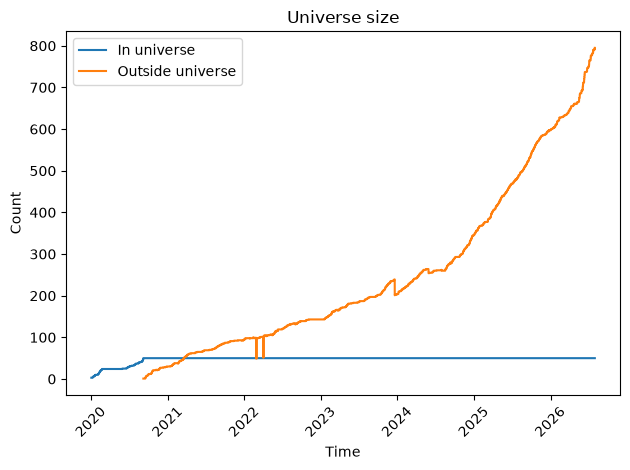

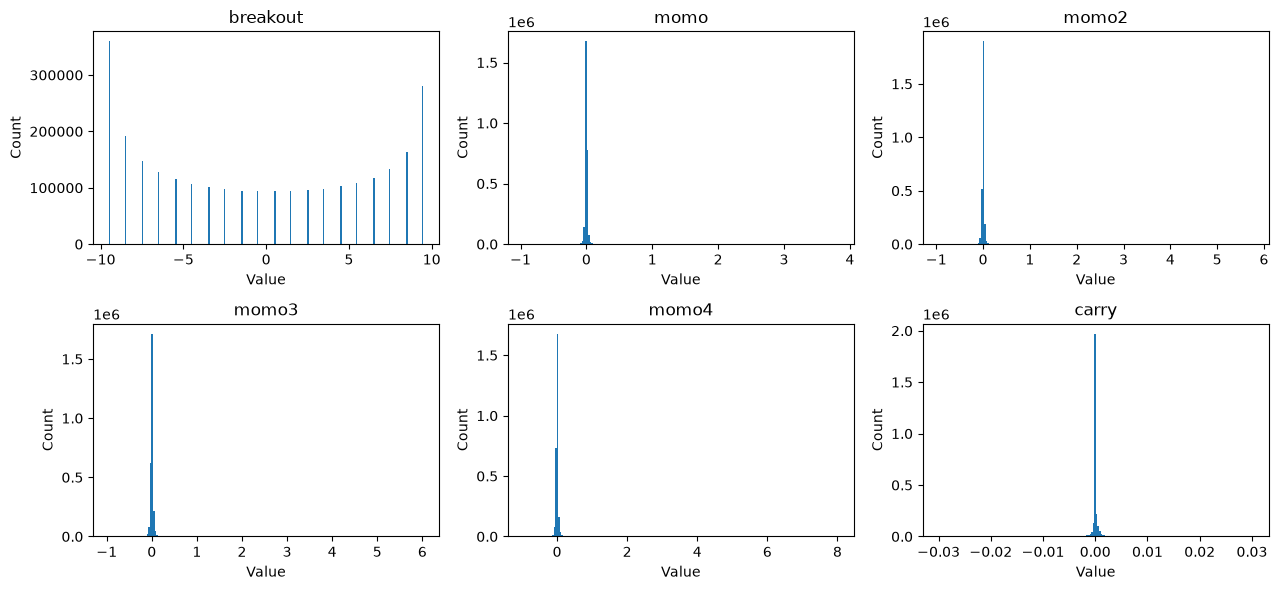

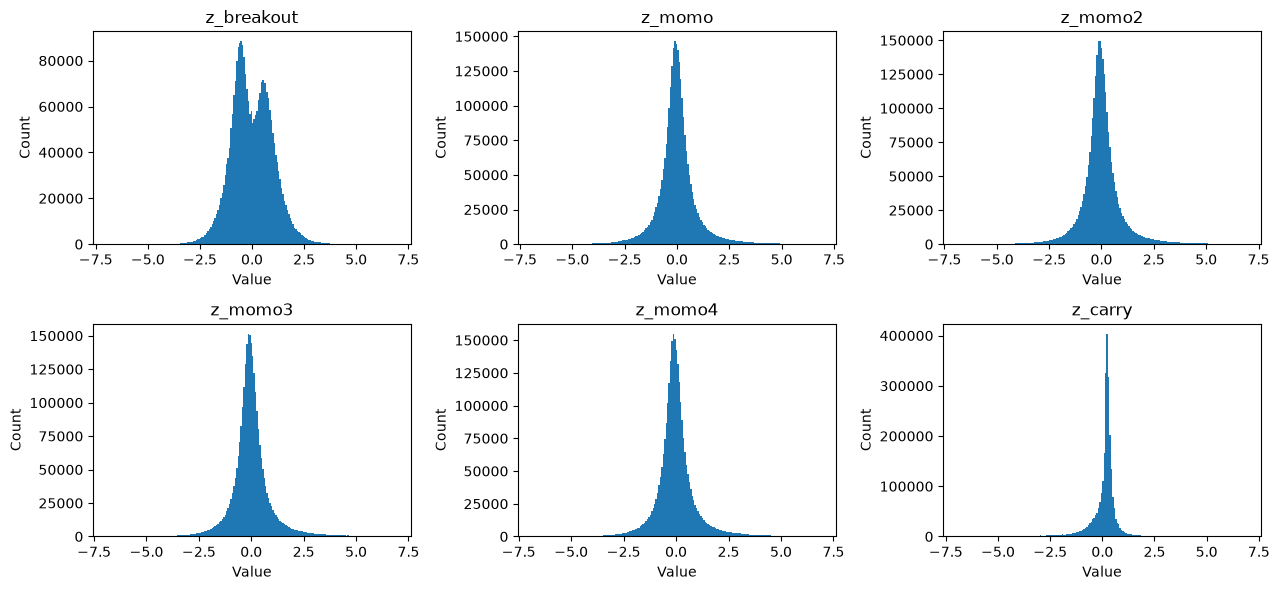

In [ ]:
plot_universe_history(base_panel)
plot_histograms(analysis_panel, [spec.name for spec in FACTOR_SPECS])
plot_histograms(analysis_panel, [f"z_{spec.name}" for spec in FACTOR_SPECS])

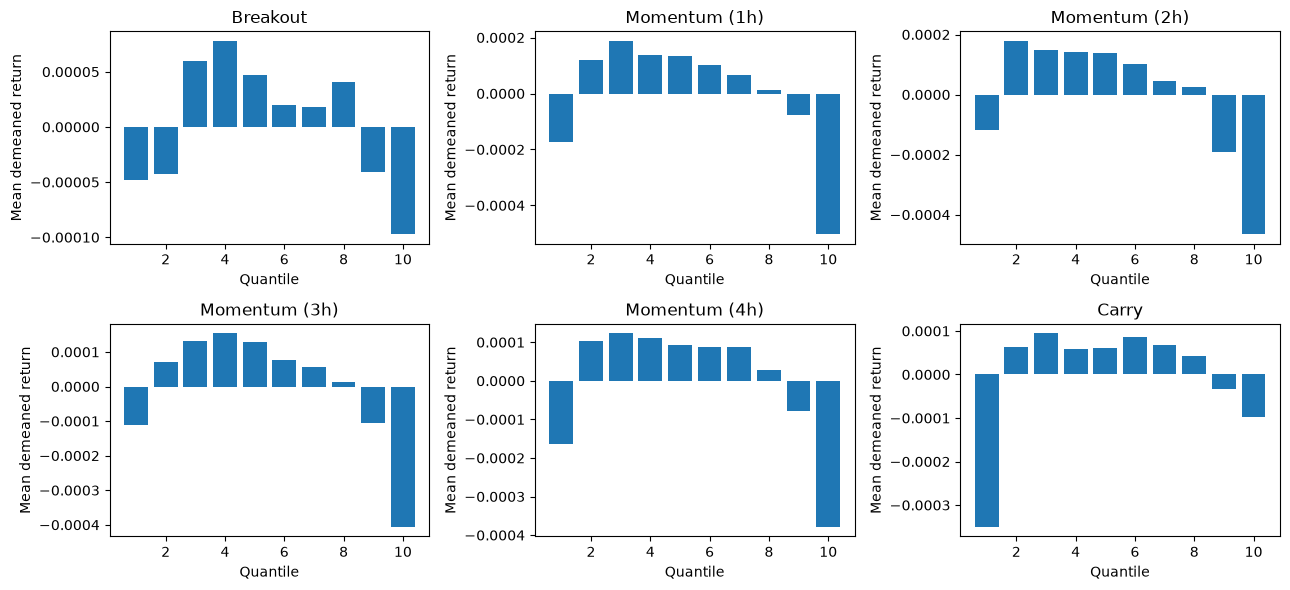

In [ ]:
plot_quantile_returns(
    analysis_panel,
    FACTOR_SPECS,
    return_column="demeaned_rets_without_funding",
)

## 5. Annual factor analysis

按年度比较各因子分位数组合的平均去中心化远期收益。绘图函数直接接收 `FACTOR_SPECS`，新增因子注册后可自动复用。

In [ ]:
annual_factor_returns = plot_annual_quantile_returns(
    analysis_panel,
    FACTOR_SPECS,
    return_column="demeaned_rets_without_funding",
    columns_per_row=3,
)
annual_factor_returns["momo"]

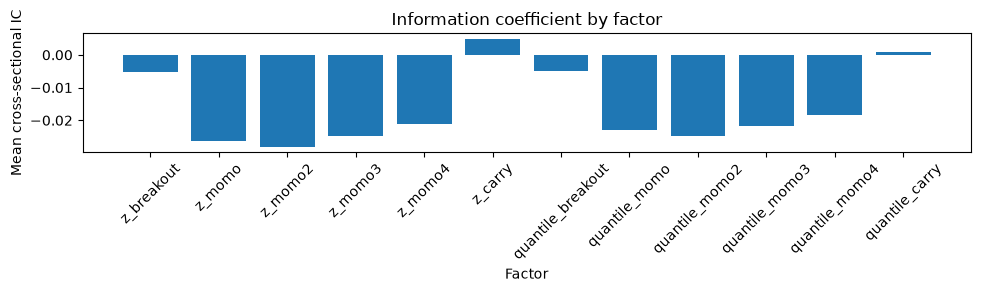

factor,mean_ic,ic_std,periods,ic_ir
str,f64,f64,u32,f64
"""z_breakout""",-0.005195,0.214351,57439,-0.024237
"""z_momo""",-0.026427,0.314907,57638,-0.083921
"""z_momo2""",-0.02805,0.31979,57638,-0.087715
"""z_momo3""",-0.024915,0.320951,57637,-0.077628
"""z_momo4""",-0.021248,0.320877,57636,-0.066219
…,…,…,…,…
"""quantile_momo""",-0.022975,0.226021,57639,-0.101652
"""quantile_momo2""",-0.024708,0.227963,57638,-0.108385
"""quantile_momo3""",-0.02169,0.228449,57637,-0.094947


In [ ]:
ic_series, ic_summary = information_coefficient_summary(analysis_panel, FACTOR_SPECS)
plot_ic_summary(ic_summary)
ic_summary

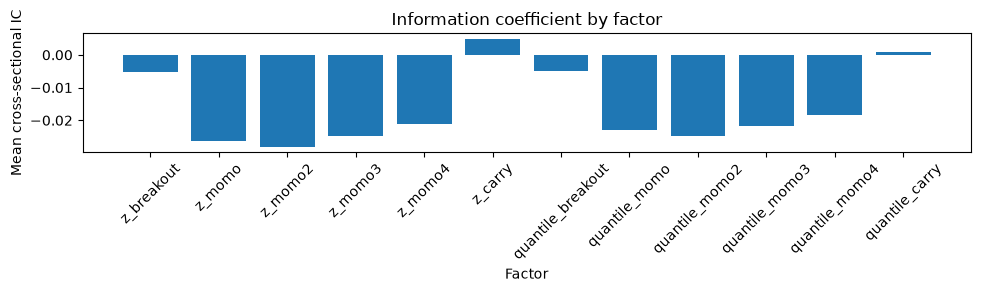

factor,mean_ic,ic_std,periods,ic_ir
str,f64,f64,u32,f64
"""z_breakout""",-0.005195,0.214351,57439,-0.024237
"""z_momo""",-0.026427,0.314907,57638,-0.083921
"""z_momo2""",-0.02805,0.31979,57638,-0.087715
"""z_momo3""",-0.024915,0.320951,57637,-0.077628
"""z_momo4""",-0.021248,0.320877,57636,-0.066219
…,…,…,…,…
"""quantile_momo""",-0.022975,0.226021,57639,-0.101652
"""quantile_momo2""",-0.024708,0.227963,57638,-0.108385
"""quantile_momo3""",-0.02169,0.228449,57637,-0.094947


In [ ]:
ic_series, ic_summary = information_coefficient_summary(
    analysis_panel,
    FACTOR_SPECS,
    return_column="log_rets_without_funding",
)
plot_ic_summary(ic_summary)
ic_summary

## 6. Forward-period IC decay

衡量当前因子与未来第 1～7 个 bar 的单期收益之间的横截面 IC。`period=1` 是 `t→t+1`，`period=2` 是 `t+1→t+2`；这不是从 `t` 开始的累计收益。

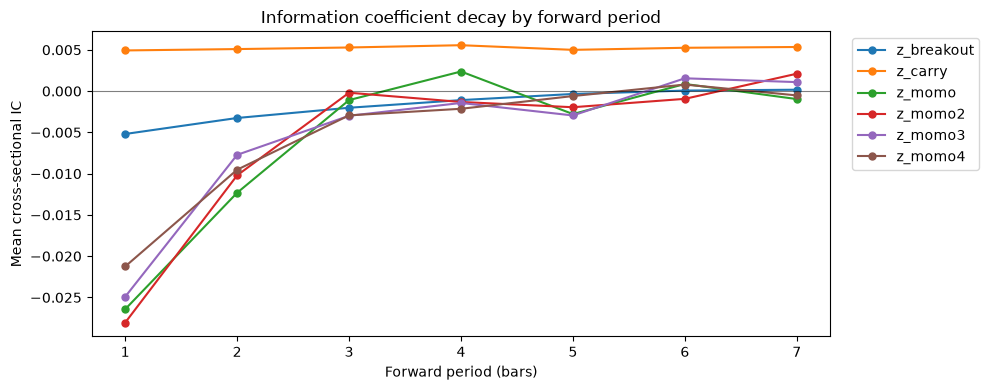

factor,forward_period,mean_ic,ic_std,periods,ic_ir
str,u16,f64,f64,u32,f64
"""z_breakout""",1,-0.005195,0.214351,57439,-0.024237
"""z_breakout""",2,-0.003256,0.2122,57438,-0.015346
"""z_breakout""",3,-0.002018,0.210963,57437,-0.009565
"""z_breakout""",4,-0.001091,0.209991,57436,-0.005196
"""z_breakout""",5,-0.000347,0.209331,57435,-0.001658
…,…,…,…,…,…
"""z_momo4""",3,-0.002939,0.298994,57634,-0.009831
"""z_momo4""",4,-0.002142,0.292282,57633,-0.007329
"""z_momo4""",5,-0.000599,0.28941,57632,-0.00207


In [ ]:
IC_DECAY_FACTORS = [f"z_{spec.name}" for spec in FACTOR_SPECS]
forward_ic_series, forward_ic_summary = forward_period_ic_summary(
    analysis_panel,
    base_panel,
    FACTOR_SPECS,
    CONFIG,
    periods=range(1, 8),
    return_column="log_rets_without_funding",
    factor_columns=IC_DECAY_FACTORS,
)
plot_forward_period_ic(forward_ic_summary)
forward_ic_summary

## 7. Factor correlation matrix

使用每对因子各自的有效样本计算 Pearson 相关系数，并绘制下三角热力图。

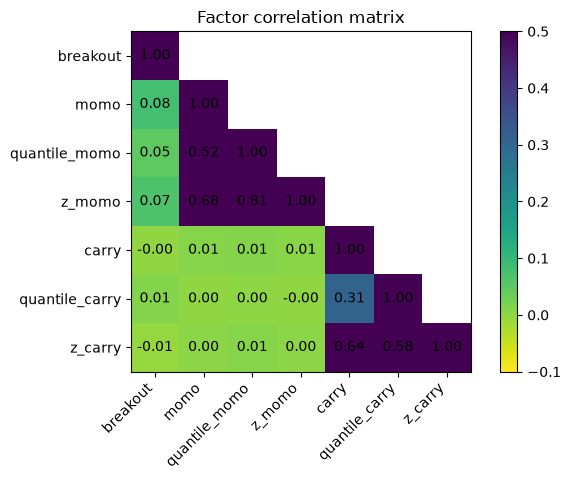

breakout,momo,quantile_momo,z_momo,carry,quantile_carry,z_carry
f64,f64,f64,f64,f64,f64,f64
1.0,0.080266,0.047786,0.067927,-0.001381,0.011001,-0.005502
0.080266,1.0,0.516153,0.678764,0.008953,0.000191,0.003704
0.047786,0.516153,1.0,0.810303,0.010252,0.003078,0.008658
0.067927,0.678764,0.810303,1.0,0.006639,-0.000097,0.003589
-0.001381,0.008953,0.010252,0.006639,1.0,0.309073,0.638376
0.011001,0.000191,0.003078,-0.000097,0.309073,1.0,0.580771
-0.005502,0.003704,0.008658,0.003589,0.638376,0.580771,1.0


In [ ]:
CORRELATION_FACTORS = [
    column
    for column in [
        "breakout",
        "momo",
        "quantile_momo",
        "z_momo",
        "carry",
        "quantile_carry",
        "z_carry",
    ]
    if column in analysis_panel.columns
]
factor_correlation = factor_correlation_matrix(analysis_panel, CORRELATION_FACTORS)
plot_factor_correlation_heatmap(factor_correlation, vmin=-0.1, vmax=0.5)
factor_correlation

## 8. Blended model weights

将 carry、momentum 和 breakout 合成为组合信号，并在每个时间截面把组合总绝对权重归一化为 1。三个分项权重包含各自的混合系数，因此它们之和严格等于最终 `scaled_weight`。

In [ ]:
MODEL_WEIGHT_CONFIG = ModelWeightConfig(
    min_universe_size=3,
    carry_coefficient=0.2,
    momentum_coefficient=-0.5,
    breakout_coefficient=0.3,
    breakout_scale=2.0,
)
model_start_timestamp, model_df = build_model_weights(
    analysis_panel,
    CONFIG,
    MODEL_WEIGHT_CONFIG,
    return_column="log_rets_without_funding",
)
print(f"Model start: {model_start_timestamp}")
model_df

Model start: 2020-01-03 02:00:00+00:00


instrument_id,timestamp,open,high,low,close,volume,funding_rate,funding_cashflow,trail_volume,volume_rank,is_universe,exit_time,return_is_valid,funding_paid,rets_without_funding,rets_with_funding,log_rets_without_funding,log_rets_with_funding,breakout,momo,momo2,momo3,momo4,carry,demeaned_rets_with_funding,demeaned_rets_without_funding,z_breakout,quantile_breakout,z_momo,quantile_momo,z_momo2,quantile_momo2,z_momo3,quantile_momo3,z_momo4,quantile_momo4,z_carry,quantile_carry,carry_weight,momo_weight,breakout_weight,carry_contribution,momo_contribution,breakout_contribution,combined_weight,gross_weight,scaled_weight,scaled_carry_weight,scaled_momo_weight,scaled_breakout_weight
str,"datetime[μs, UTC]",f64,f64,f64,f64,f64,f64,f64,f64,u32,bool,"datetime[μs, UTC]",bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u8,f64,u8,f64,u8,f64,u8,f64,u8,f64,u8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""BCHUSDT""",2020-01-03 02:00:00 UTC,192.45,195.99,192.13,195.66,2.5436e6,0.0001,0.0,2.5293e6,3,true,2020-01-03 03:00:00 UTC,true,0.0,0.016939,0.016939,0.016798,0.016798,-5.5,-0.010436,-0.016605,-0.015548,-0.012417,0.0001,0.00545,0.00545,1.0,10,-1.097508,4,-1.114029,4,-1.079415,4,0.910252,10,0.57735,7,1.5,-1.5,-2.75,0.3,0.75,-0.825,0.225,4.725,0.047619,0.063492,0.15873,-0.174603
"""BTCUSDT""",2020-01-03 02:00:00 UTC,6884.72,6960.0,6863.44,6952.58,5.7938e7,-0.000017,0.0,3.2513e7,1,true,2020-01-03 03:00:00 UTC,true,0.0,0.009858,0.009858,0.00981,0.00981,-6.5,-0.007143,-0.011103,-0.012283,-0.012728,-0.000017,-0.001538,-0.001538,0.0,7,0.859572,10,0.293947,7,0.184534,7,0.160164,7,-1.154701,4,-1.5,4.5,-3.25,-0.3,-2.25,-0.975,-3.525,4.725,-0.746032,-0.063492,-0.47619,-0.206349
"""ETHUSDT""",2020-01-03 02:00:00 UTC,125.96,127.01,125.8,126.91,3.0249e6,0.0001,0.0,2.8632e6,2,true,2020-01-03 03:00:00 UTC,true,0.0,0.007463,0.007463,0.007435,0.007435,-7.5,-0.008189,-0.009047,-0.010449,-0.013239,0.0001,-0.003912,-0.003912,-1.0,4,0.237936,7,0.820082,10,0.89488,10,-1.070415,4,0.57735,10,4.5,1.5,-3.75,0.9,-0.75,-1.125,-0.975,4.725,-0.206349,0.190476,-0.15873,-0.238095
"""BCHUSDT""",2020-01-03 03:00:00 UTC,195.71,195.93,195.0,195.7,1.1009e6,0.0001,0.0,2.5387e6,3,true,2020-01-03 04:00:00 UTC,true,0.0,-0.000051,-0.000051,-0.000051,-0.000051,-6.5,0.016521,0.005912,-0.000358,0.000716,0.0001,0.000449,0.000449,1.0,10,1.118657,10,0.996081,10,1.138799,10,1.148024,10,0.57735,7,1.5,4.5,-3.25,0.3,-2.25,-0.975,-2.925,5.475,-0.534247,0.054795,-0.410959,-0.178082
"""BTCUSDT""",2020-01-03 03:00:00 UTC,6952.59,6958.5,6935.74,6947.35,1.7753e7,-0.000017,0.0,3.4088e7,1,true,2020-01-03 04:00:00 UTC,true,0.0,-0.000741,-0.000741,-0.000741,-0.000741,-7.5,0.009854,0.002641,-0.001359,-0.002551,-0.000017,-0.00024,-0.00024,0.0,7,-0.311427,7,0.007792,7,-0.404014,7,-0.466633,7,-1.154701,4,-1.5,1.5,-3.75,-0.3,-0.75,-1.125,-2.175,5.475,-0.39726,-0.054795,-0.136986,-0.205479
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""UNIUSDT""",2026-07-30 22:00:00 UTC,4.401,4.442,4.392,4.409,3.7613e6,0.0001,0.0,5.2913e6,44,true,2026-07-30 23:00:00 UTC,true,0.0,0.001818,0.001818,0.001816,0.001816,4.5,0.001365,-0.002041,0.00342,-0.009007,0.0001,-0.003934,-0.003934,0.165936,5,-0.038747,7,-0.217292,5,-0.07024,6,-0.184372,3,0.160688,8,2.5,1.5,2.25,0.5,-0.75,0.675,0.425,56.35,0.007542,0.008873,-0.01331,0.011979
"""XAGUSDT""",2026-07-30 22:00:00 UTC,59.1,59.19,59.07,59.15,9.1647e6,0.000116,0.0,4.3156e7,13,true,2026-07-30 23:00:00 UTC,true,0.0,0.000677,0.000677,0.000677,0.000677,7.5,0.0,-0.003204,0.002884,0.004418,0.000116,-0.005073,-0.005073,0.626871,7,-0.147101,5,-0.261135,4,-0.083909,5,0.089029,6,0.201918,8,2.5,-0.5,3.75,0.5,0.25,1.125,1.875,56.35,0.033274,0.008873,0.004437,0.019965
"""XAUUSDT""",2026-07-30 22:00:00 UTC,4113.52,4117.81,4109.4,4116.32,2.7678e7,0.0000527,0.0,9.7203e7,8,true,2026-07-30 23:00:00 UTC,true,0.0,0.00072,0.00072,0.000719,0.000719,1.5,0.000418,-0.001272,0.001605,0.001056,0.0000527,-0.005031,-0.005031,-0.294998,5,-0

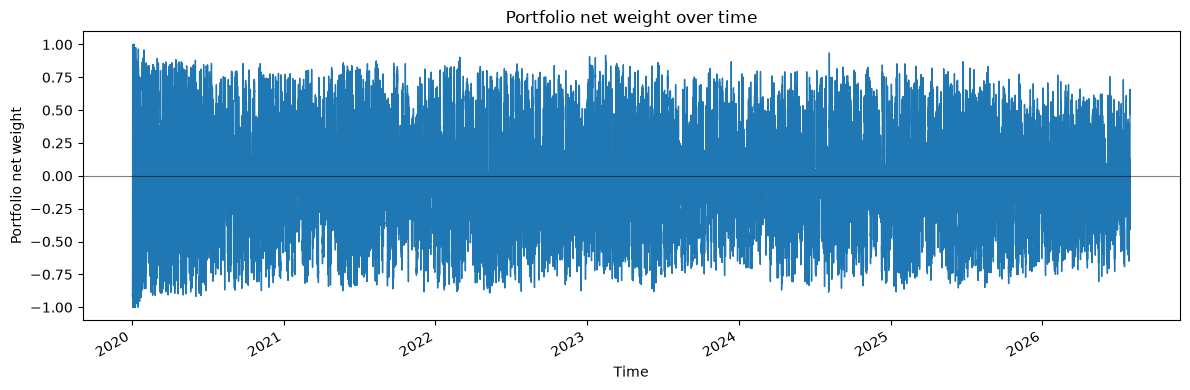

timestamp,net_weight
"datetime[μs, UTC]",f64
2020-01-03 02:00:00 UTC,-0.904762
2020-01-03 03:00:00 UTC,-0.863014
2020-01-03 04:00:00 UTC,-0.92
2020-01-03 05:00:00 UTC,-0.686275
2020-01-03 06:00:00 UTC,0.263158
…,…
2026-07-30 18:00:00 UTC,0.626923
2026-07-30 19:00:00 UTC,0.5163
2026-07-30 20:00:00 UTC,0.494497


In [ ]:
portfolio_net_weights = plot_portfolio_net_weight(model_df)
portfolio_net_weights

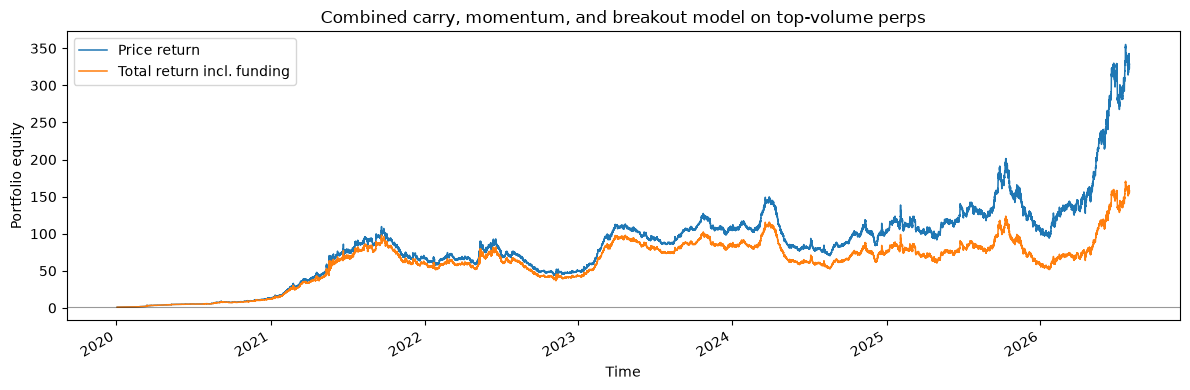

timestamp,portfolio_rets_without_funding,portfolio_rets_with_funding,equity_rets_without_funding,equity_rets_with_funding
"datetime[μs, UTC]",f64,f64,f64,f64
2020-01-03 02:00:00 UTC,-0.008088,-0.008088,0.991912,0.991912
2020-01-03 03:00:00 UTC,0.000273,0.000273,0.992183,0.992183
2020-01-03 04:00:00 UTC,-0.03539,-0.03539,0.957069,0.957069
2020-01-03 05:00:00 UTC,-0.003711,-0.003711,0.953518,0.953518
2020-01-03 06:00:00 UTC,-0.003335,-0.003335,0.950338,0.950338
…,…,…,…,…
2026-07-30 18:00:00 UTC,-0.009847,-0.009847,322.581795,155.201016
2026-07-30 19:00:00 UTC,0.013575,0.013575,326.96081,157.307854
2026-07-30 20:00:00 UTC,0.005186,0.005186,328.656389,158.123633


In [ ]:
portfolio_equity = build_portfolio_equity_curve(model_df)
plot_portfolio_equity_curve(
    portfolio_equity,
    equity_columns=[
        "equity_rets_without_funding",
        "equity_rets_with_funding",
    ],
    title="Combined carry, momentum, and breakout model on top-volume perps",
)
portfolio_equity

In [ ]:
factor_attribution = build_factor_return_attribution(
    model_df,
    return_column="rets_without_funding",
)
plot_factor_return_attribution(factor_attribution)
factor_attribution

## 9. Rolling regressions

每隔固定天数，使用此前已经实现的 30 天远期收益拟合 pooled cross-sectional OLS。系数从估计时点开始向前持有，避免用未来窗口或向后填充造成前视偏差。

In [ ]:
REGRESSION_FEATURES = ("carry_weight", "momo_weight", "breakout_weight")
ROLLING_REGRESSION_CONFIG = RollingRegressionConfig(
    lookback_days=30,
    refit_every_days=10,
    min_observations=100,
)

regression_df = build_regression_frame(model_df, CONFIG)
rolling_coefficients = rolling_cross_sectional_ols(
    regression_df,
    target_column="demeaned_rets_without_funding",
    feature_columns=REGRESSION_FEATURES,
    config=ROLLING_REGRESSION_CONFIG,
)
daily_coefficients = expand_coefficients_daily(
    rolling_coefficients, regression_df
)
plot_rolling_coefficients(daily_coefficients, REGRESSION_FEATURES)
daily_coefficients

In [ ]:
expected_return_df = add_regression_expected_returns(
    regression_df,
    daily_coefficients,
    REGRESSION_FEATURES,
)
expected_return_df.select(
    "timestamp",
    "instrument_id",
    "last_refit_at",
    *[f"coef_{feature}" for feature in REGRESSION_FEATURES],
    *[
        f"expected_{feature.removesuffix('_weight')}_return"
        for feature in REGRESSION_FEATURES
    ],
    "expected_return",
)

## 10. Add a factor

新增因子只需定义一个返回 Polars 表达式的函数，并注册到 `FACTOR_SPECS`。例如：

```python
def volatility_expression(_: AnalysisConfig) -> pl.Expr:
    return pl.col("close").pct_change().rolling_std(24).shift(1).over("instrument_id")

FACTOR_SPECS = (*FACTOR_SPECS, FactorSpec("volatility", volatility_expression, "Volatility (24h)"))
base_panel, analysis_panel = build_analysis_panel(CONFIG, FACTOR_SPECS)
```